# **Fake News Detection Model Training**

This notebook creates a BERT-based machine learning model designed to predict whether a news article is fake or real. The notebook follows the same structure as the sentiment analysis training but adapted for fake news classification.

The input file should be formatted with the following:
1. An "Article" column containing the news text
2. A "Truth" column with 0 (fake) or 1 (real)

### Preparing Tools and Files

In [ ]:
# ! pip install torch
# ! pip install transformers
# ! pip install numpy
# ! pip install pandas
# ! pip install datasets

In [5]:
import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, get_scheduler
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from datasets import Dataset

c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Load the reduced/cleaned fake news dataset
df = pd.read_csv('../data/processed/01/reduced_dataset.csv')
df.head()

,Article,Truth,Source
0,celebrities join tax march protest donald trum...,0,gossipcop
1,heres really happened jfk jr met princess dian...,0,gossipcop
2,angelina jolie cant get heartbreak losing brad...,0,gossipcop
3,oscar nominations 2018 complete list oscar nom...,0,gossipcop
4,hes hired ben affleck enlists best friend matt...,0,gossipcop


### Preprocessing

The goal of preprocessing is to turn human-readable data into computer-readable training data.

First, we will check the dataset for missing parameters and remove them. We'll also allow you to select how much of the dataset you want to use for training.

In [79]:
df.isna().sum()

# Check class distribution
print("Class distribution:")
print(df['Truth'].value_counts())

Class distribution:
Truth
1    32232
0    26269
Name: count, dtype: int64


Now, we're going to trim down this dataset. Choose how many samples you want to use for training:

In [7]:
# 🎛️ DATASET SIZE SELECTOR - Choose how much data to train on
# Options: 1000 (fast), 5000 (medium), 10000 (slower), or len(df) (full dataset)
DATASET_SIZE = 1000  # Change this number to control training size and speed

print(f"Full dataset size: {len(df)}")

# Get balanced sample with equal fake and real news
fake_news = df[df['Truth'] == 0].head(DATASET_SIZE // 2)
real_news = df[df['Truth'] == 1].head(DATASET_SIZE // 2)
df = pd.concat([fake_news, real_news]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Selected dataset size: {len(df)}")

# Check balance after reduction
print(f"\nClass balance after reduction:")
print(df['Truth'].value_counts())

Full dataset size: 58501
Selected dataset size: 1000

Class balance after reduction:
Truth
1    500
0    500
Name: count, dtype: int64


Next, we'll tokenize the words. This takes the words and turns them into "tokens", chunks of information that can be read and understood by the computer.

In [8]:
# Create HuggingFace dataset
dataset = Dataset.from_pandas(df)

# Rename Truth column to labels (required by BERT model)
dataset = dataset.rename_column("Truth", "labels")

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["Article"], padding=True, truncation=True, max_length=128)

# Apply tokenizer
dataset_enc = dataset.map(tokenize, batched=True, remove_columns=["Article", "Source"])
dataset_enc = dataset_enc.train_test_split(test_size=0.2)

Map: 100%|██████████| 1000/1000 [00:00<00:00, 6331.57 examples/s]



Next, we want to convert these to pytorch tensors, objects that can be read by the pytorch library.

In [9]:
dataset_enc.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

The last few tools are the dataloaders and collators.

* The dataloaders will make sure we're sending small batches of articles/labels. The training data will be shuffled, making sure that the model isn't training for unintended patterns.

* The collator helps with efficiency of space and time by increasing the size of all tokens to the largest token in the batch.

In [10]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [11]:
# Dataloaders
train_dataloader = DataLoader(
    dataset_enc["train"], shuffle=True, batch_size=8, collate_fn=data_collator
)
eval_dataloader = DataLoader(
    dataset_enc["test"], batch_size=5, collate_fn=data_collator
)

## Processing

First we load the model to be trained.

In [12]:
num_labels = 2 # fake and real, or 0 and 1
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=num_labels
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Now let's define some parameters for how the model will train.

* learning rate: how much the model will adjust its weights based on error.

* epochs: how many times the model will go through the entire dataset.

**Training is made up of epochs, epochs are made up of batches, batches are made up of entries.**

In [13]:
learning_rate = 5e-5
num_epochs = 3

We'll set up a dynamic learning rate, shrinking over time as we get closer. Our first few runs will be rough, but as it gets better at prediction (lower loss), we want our adjustments to be smaller with it.

In [15]:
optimizer = AdamW(model.parameters(), lr=learning_rate)
num_training_batches = len(train_dataloader)
num_training_steps = num_epochs * num_training_batches
lr_scheduler = get_scheduler("linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

Now we specify which part of the computer will process this. We'll use CPU to avoid GPU memory issues and ensure stable training.

In [16]:
device = torch.device("cpu")  # Use CPU for stable training
model.to(device)
progress_bar = tqdm(range(num_training_steps)) # for convenience
model.train()

  0%|          | 0/300 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [17]:
# Load the pre-trained model if it exists
import os
model_save_path = '../models/bert_fake_news_trained'

if os.path.exists(model_save_path):
    print("Loading pre-trained model...")
    model = AutoModelForSequenceClassification.from_pretrained(model_save_path)
    tokenizer = AutoTokenizer.from_pretrained(model_save_path)
    model.to(device)
    print("✅ Pre-trained model loaded successfully!")
else:
    print("No pre-trained model found. Using the fresh model.")

model.eval()  # Set to evaluation mode

Loading pre-trained model...
✅ Pre-trained model loaded successfully!


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

Training Loop:

Epoch 1 of 3


 33%|███▎      | 100/300 [03:14<06:22,  1.91s/it]

Average Loss: 0.6553
Epoch 2 of 3


 67%|██████▋   | 200/300 [06:29<03:15,  1.95s/it]

Average Loss: 0.4866
Epoch 3 of 3


100%|██████████| 300/300 [09:45<00:00,  1.92s/it]

Average Loss: 0.2891


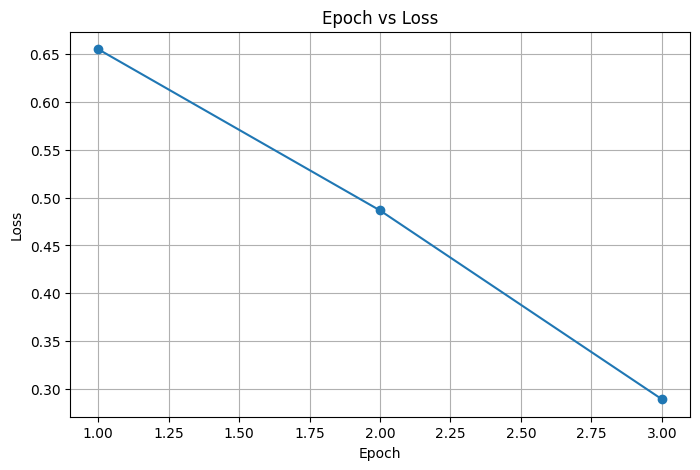

In [97]:
import matplotlib.pyplot as plt

train_losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1} of {num_epochs}")
    running_loss = 0.0

    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        progress_bar.update(1)

    avg_loss = running_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f"Average Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.grid(True)
plt.show()

To keep persistent, save the weights to a file

In [60]:
model_save_path = '../models/bert_fake_news_trained'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

('../models/bert_fake_news_trained\\tokenizer_config.json',
 '../models/bert_fake_news_trained\\special_tokens_map.json',
 '../models/bert_fake_news_trained\\vocab.txt',
 '../models/bert_fake_news_trained\\added_tokens.json',
 '../models/bert_fake_news_trained\\tokenizer.json')

## Model Evaluation and Analysis

Now let's comprehensively evaluate our trained BERT model using multiple metrics and visualizations.

In [21]:
# Import additional libraries for evaluation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
import seaborn as sns

print("=== BERT Model Evaluation ===")
print("Calculating comprehensive metrics...")

=== BERT Model Evaluation ===
Calculating comprehensive metrics...


In [18]:
# Evaluation Function
def evaluate_model(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []
    prediction_probs = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(**batch)
            logits = outputs.logits
            
            # Get probabilities and predictions
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(logits, dim=-1)
            
            # Store results
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['labels'].cpu().numpy())
            prediction_probs.extend(probs.cpu().numpy())
    
    return np.array(true_labels), np.array(predictions), np.array(prediction_probs)

# Run evaluation on test set
print("Evaluating on test set...")
true_labels, predictions, probs = evaluate_model(model, eval_dataloader, device)

Evaluating on test set...


Evaluating: 100%|██████████| 40/40 [00:12<00:00,  3.31it/s]


In [19]:
# Calculate All Metrics
print("\n=== COMPREHENSIVE METRICS ===")

# Basic metrics
accuracy = accuracy_score(true_labels, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='weighted')

# ROC-AUC (using probabilities for positive class)
roc_auc = roc_auc_score(true_labels, probs[:, 1])

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Detailed classification report
print(f"\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predictions, target_names=['Fake News', 'Real News']))


=== COMPREHENSIVE METRICS ===
Accuracy:  0.6500
Precision: 0.6533
Recall:    0.6500
F1-Score:  0.6500
ROC-AUC:   0.7556

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   Fake News       0.62      0.68      0.65        95
   Real News       0.68      0.62      0.65       105

    accuracy                           0.65       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.65      0.65      0.65       200




=== CONFUSION MATRIX ===


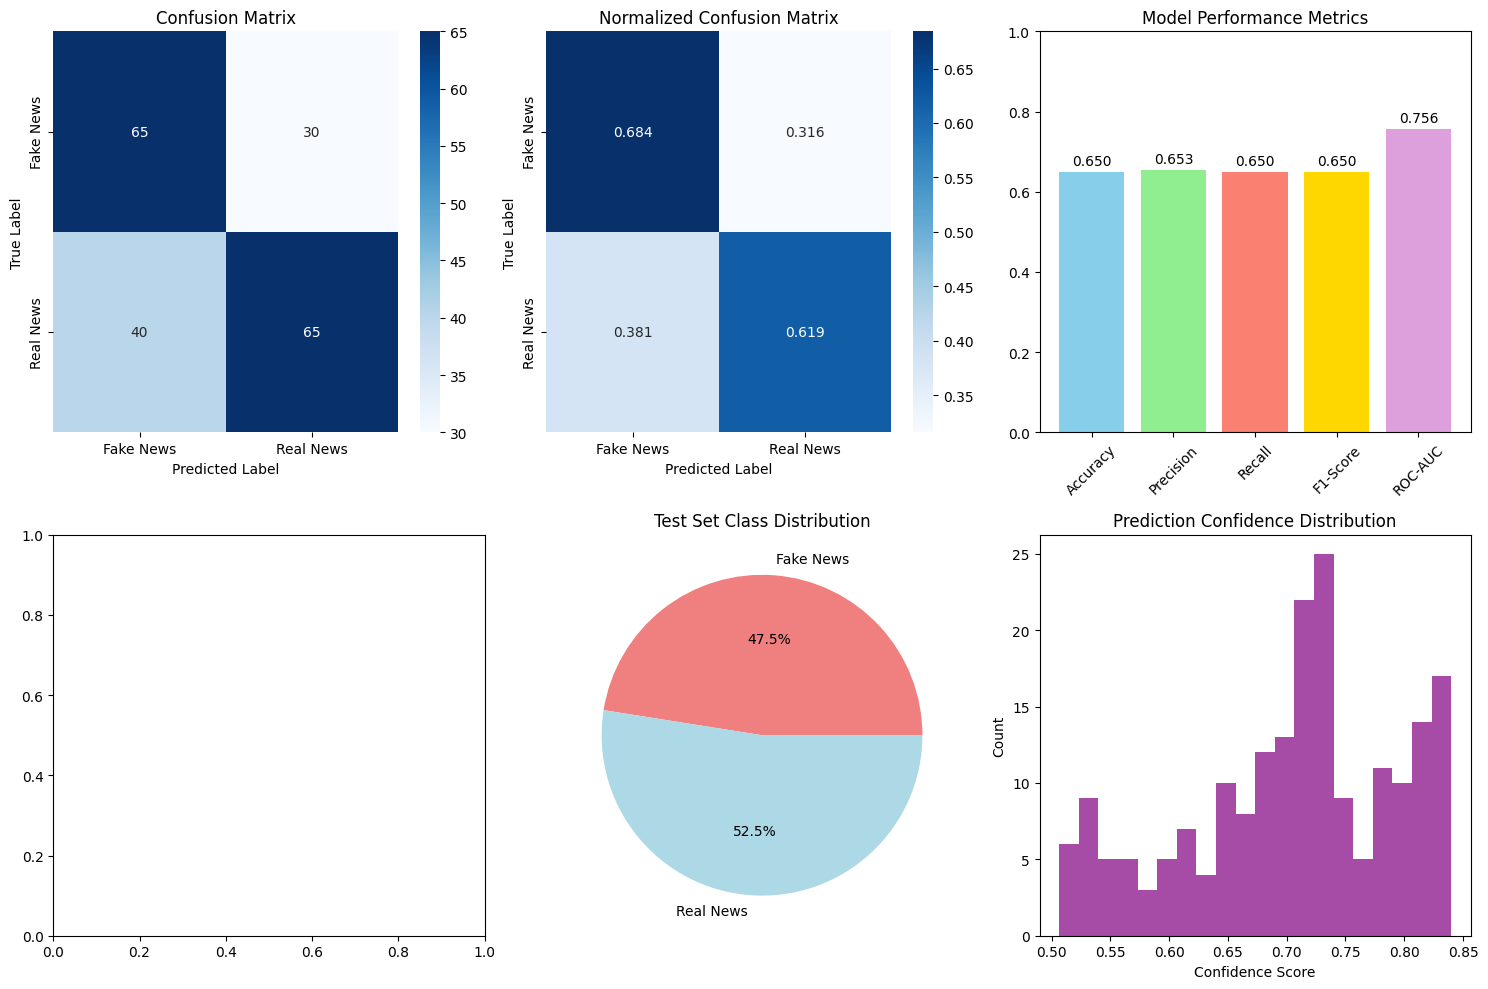


Confusion Matrix Breakdown:
True Negatives (Correctly predicted Fake): 65
False Positives (Fake predicted as Real): 30
False Negatives (Real predicted as Fake): 40
True Positives (Correctly predicted Real): 65

Sensitivity (True Positive Rate): 0.6190
Specificity (True Negative Rate): 0.6842


In [22]:
# Generate and Visualize Confusion Matrix
print("\n=== CONFUSION MATRIX ===")

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Create visualization
plt.figure(figsize=(15, 10))

# Confusion Matrix Plot
plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Normalized Confusion Matrix
plt.subplot(2, 3, 2)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Metrics Comparison Bar Chart
plt.subplot(2, 3, 3)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [accuracy, precision, recall, f1, roc_auc]
bars = plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'gold', 'plum'])
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom')

# Training Loss Curve
plt.subplot(2, 3, 4)
if 'train_losses' in locals():
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='red')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

# Class Distribution
plt.subplot(2, 3, 5)
class_counts = [np.sum(true_labels == 0), np.sum(true_labels == 1)]
plt.pie(class_counts, labels=['Fake News', 'Real News'], autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
plt.title('Test Set Class Distribution')

# Prediction Confidence Distribution
plt.subplot(2, 3, 6)
confidence_scores = np.max(probs, axis=1)
plt.hist(confidence_scores, bins=20, alpha=0.7, color='purple')
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print confusion matrix details
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted Fake): {cm[0,0]}")
print(f"False Positives (Fake predicted as Real): {cm[0,1]}")
print(f"False Negatives (Real predicted as Fake): {cm[1,0]}")
print(f"True Positives (Correctly predicted Real): {cm[1,1]}")

# Calculate additional metrics
sensitivity = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0

print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")


=== K-FOLD CROSS-VALIDATION ===
Running 5-fold cross-validation...
Note: This will take several minutes as we train 5 mini-models

Fold 1/5


Map: 100%|██████████| 200/200 [00:00<00:00, 4746.14 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating: 100%|██████████| 25/25 [00:10<00:00,  2.41it/s]
c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  Accuracy: 0.5000, F1: 0.3333, ROC-AUC: 0.7252

Fold 2/5


Map: 100%|██████████| 200/200 [00:00<00:00, 4419.76 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating: 100%|██████████| 25/25 [00:10<00:00,  2.45it/s]
c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  Accuracy: 0.5000, F1: 0.3333, ROC-AUC: 0.6444

Fold 3/5


...

  Accuracy: 0.5050, F1: 0.3608, ROC-AUC: 0.6291

Fold 4/5


Map: 100%|██████████| 200/200 [00:00<00:00, 4508.77 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating: 100%|██████████| 25/25 [00:09<00:00,  2.53it/s]


  Accuracy: 0.5900, F1: 0.5818, ROC-AUC: 0.6643

Fold 5/5


Map: 100%|██████████| 200/200 [00:00<00:00, 4479.68 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating: 100%|██████████| 25/25 [00:10<00:00,  2.46it/s]

  Accuracy: 0.4900, F1: 0.3373, ROC-AUC: 0.6457

=== CROSS-VALIDATION SUMMARY ===
Accuracy:  0.5170 ± 0.0368
Precision: 0.4043 ± 0.1467
Recall:    0.5170 ± 0.0368
F1-Score:  0.3893 ± 0.0968
ROC-AUC:   0.6617 ± 0.0336


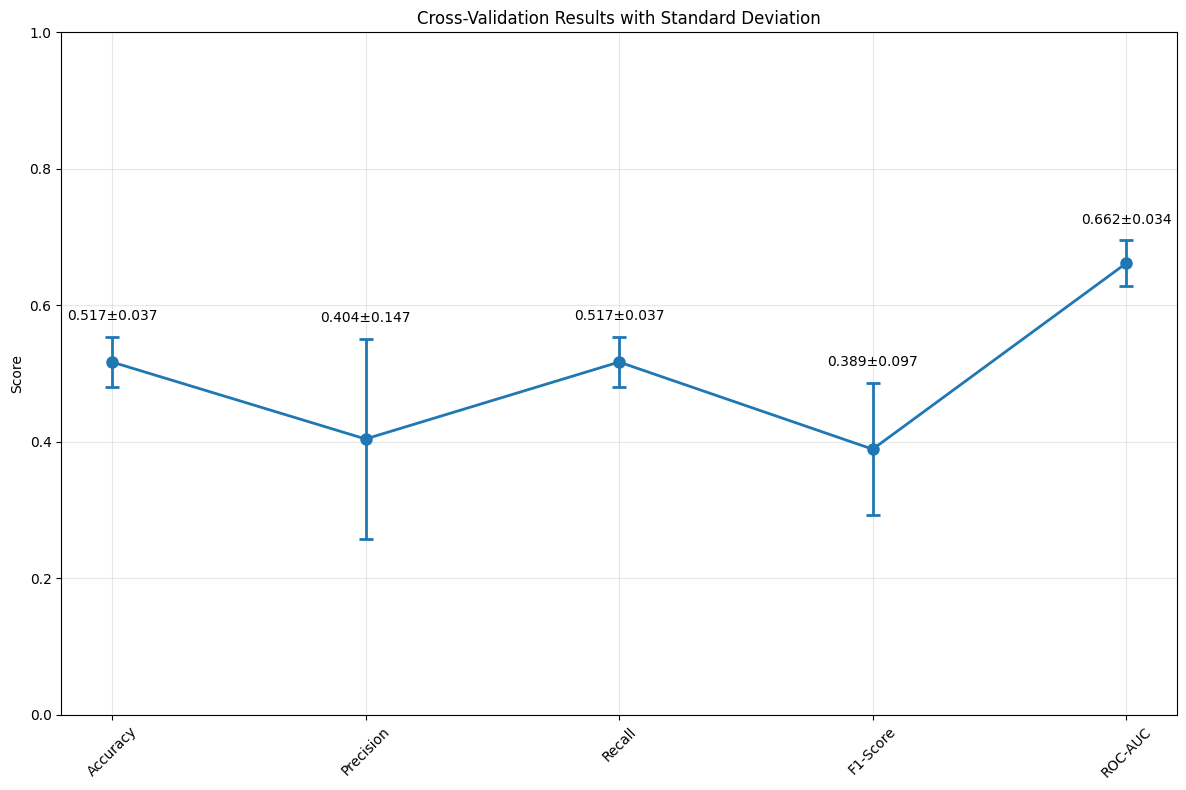

In [24]:
# K-Fold Cross-Validation
print("\n=== K-FOLD CROSS-VALIDATION ===")

# Prepare data for K-fold
X = df['Article'].values
y = df['Truth'].values

# Initialize K-fold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each fold
cv_accuracies = []
cv_f1_scores = []
cv_precisions = []
cv_recalls = []
cv_roc_aucs = []

print("Running 5-fold cross-validation...")
print("Note: This will take several minutes as we train 5 mini-models")

for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f"\nFold {fold + 1}/5")
    
    # Split data
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    # Create datasets
    train_df_fold = pd.DataFrame({'Article': X_train_fold, 'labels': y_train_fold})
    val_df_fold = pd.DataFrame({'Article': X_val_fold, 'labels': y_val_fold})
    
    train_dataset_fold = Dataset.from_pandas(train_df_fold)
    val_dataset_fold = Dataset.from_pandas(val_df_fold)
    
    # Tokenize
    train_dataset_fold = train_dataset_fold.map(tokenize, batched=True, remove_columns=['Article'])
    val_dataset_fold = val_dataset_fold.map(tokenize, batched=True, remove_columns=['Article'])
    
    # Set format
    train_dataset_fold.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    val_dataset_fold.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    
    # Create dataloaders
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=8, shuffle=True, collate_fn=data_collator)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=8, collate_fn=data_collator)
    
    # Create new model for this fold
    model_fold = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
    model_fold.to(device)
    
    # Quick training (1 epoch for demo - you can increase this for better results)
    optimizer_fold = AdamW(model_fold.parameters(), lr=learning_rate)
    model_fold.train()
    
    # Mini training loop
    for batch in tqdm(train_loader_fold, desc=f"Training Fold {fold+1}", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model_fold(**batch)
        loss = outputs.loss
        loss.backward()
        
        optimizer_fold.step()
        optimizer_fold.zero_grad()
    
    # Evaluate fold
    fold_true, fold_pred, fold_probs = evaluate_model(model_fold, val_loader_fold, device)
    
    # Calculate metrics
    fold_acc = accuracy_score(fold_true, fold_pred)
    fold_prec, fold_rec, fold_f1, _ = precision_recall_fscore_support(fold_true, fold_pred, average='weighted')
    fold_auc = roc_auc_score(fold_true, fold_probs[:, 1])
    
    # Store results
    cv_accuracies.append(fold_acc)
    cv_f1_scores.append(fold_f1)
    cv_precisions.append(fold_prec)
    cv_recalls.append(fold_rec)
    cv_roc_aucs.append(fold_auc)
    
    print(f"  Accuracy: {fold_acc:.4f}, F1: {fold_f1:.4f}, ROC-AUC: {fold_auc:.4f}")

# Print cross-validation results
print(f"\n=== CROSS-VALIDATION SUMMARY ===")
print(f"Accuracy:  {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")
print(f"Precision: {np.mean(cv_precisions):.4f} ± {np.std(cv_precisions):.4f}")
print(f"Recall:    {np.mean(cv_recalls):.4f} ± {np.std(cv_recalls):.4f}")
print(f"F1-Score:  {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}")
print(f"ROC-AUC:   {np.mean(cv_roc_aucs):.4f} ± {np.std(cv_roc_aucs):.4f}")

# Visualize cross-validation results
plt.figure(figsize=(12, 8))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
cv_means = [np.mean(cv_accuracies), np.mean(cv_precisions), np.mean(cv_recalls), 
           np.mean(cv_f1_scores), np.mean(cv_roc_aucs)]
cv_stds = [np.std(cv_accuracies), np.std(cv_precisions), np.std(cv_recalls), 
          np.std(cv_f1_scores), np.std(cv_roc_aucs)]

plt.errorbar(metrics_names, cv_means, yerr=cv_stds, fmt='o-', capsize=5, capthick=2, linewidth=2, markersize=8)
plt.title('Cross-Validation Results with Standard Deviation')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add value labels
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    plt.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [25]:
# Sample Predictions Analysis
print("\n=== SAMPLE PREDICTIONS ANALYSIS ===")

# Get some sample predictions to analyze
sample_indices = np.random.choice(len(true_labels), size=10, replace=False)

print("Sample predictions from test set:")
print("-" * 80)

for i, idx in enumerate(sample_indices):
    true_label = true_labels[idx]
    pred_label = predictions[idx]
    confidence = np.max(probs[idx])
    
    # Get original text from the test dataset
    test_articles = dataset_enc['test']['Article'] if 'Article' in dataset_enc['test'].column_names else None
    if test_articles:
        article_text = test_articles[idx]
    else:
        # Fallback - try to get from original dataset
        article_text = "Article text not available in processed dataset"
    
    status = "✅ CORRECT" if true_label == pred_label else "❌ INCORRECT"
    true_class = "Real News" if true_label == 1 else "Fake News"
    pred_class = "Real News" if pred_label == 1 else "Fake News"
    
    print(f"\nSample {i+1}: {status}")
    print(f"True Label: {true_class}")
    print(f"Predicted: {pred_class} (Confidence: {confidence:.3f})")
    print(f"Article: {str(article_text)[:200]}...")
    print("-" * 80)

# Performance by class
print(f"\n=== PERFORMANCE BY CLASS ===")
fake_mask = true_labels == 0
real_mask = true_labels == 1

fake_accuracy = accuracy_score(true_labels[fake_mask], predictions[fake_mask])
real_accuracy = accuracy_score(true_labels[real_mask], predictions[real_mask])

print(f"Fake News Detection Accuracy: {fake_accuracy:.4f}")
print(f"Real News Detection Accuracy: {real_accuracy:.4f}")

comparison = "better" if fake_accuracy > real_accuracy else "worse" if fake_accuracy < real_accuracy else "equal"
print(f"\nModel shows {comparison} performance on fake news detection vs real news detection")

# Error Analysis
print(f"\n=== ERROR ANALYSIS ===")
errors = true_labels != predictions
error_rate = np.mean(errors)
print(f"Overall Error Rate: {error_rate:.4f} ({np.sum(errors)} out of {len(true_labels)} predictions)")

# False positives (fake news predicted as real)
false_positives = (true_labels == 0) & (predictions == 1)
fp_rate = np.mean(false_positives)
print(f"False Positive Rate (Fake→Real): {fp_rate:.4f}")

# False negatives (real news predicted as fake)
false_negatives = (true_labels == 1) & (predictions == 0)
fn_rate = np.mean(false_negatives)
print(f"False Negative Rate (Real→Fake): {fn_rate:.4f}")

print(f"\nModel is more likely to make {'False Positive' if fp_rate > fn_rate else 'False Negative'} errors")


=== SAMPLE PREDICTIONS ANALYSIS ===
Sample predictions from test set:
--------------------------------------------------------------------------------

Sample 1: ✅ CORRECT
True Label: Fake News
Predicted: Fake News (Confidence: 0.734)
Article: Article text not available in processed dataset...
--------------------------------------------------------------------------------

Sample 2: ❌ INCORRECT
True Label: Real News
Predicted: Fake News (Confidence: 0.677)
Article: Article text not available in processed dataset...
--------------------------------------------------------------------------------

Sample 3: ✅ CORRECT
True Label: Real News
Predicted: Real News (Confidence: 0.658)
Article: Article text not available in processed dataset...
--------------------------------------------------------------------------------

Sample 4: ❌ INCORRECT
True Label: Real News
Predicted: Fake News (Confidence: 0.719)
Article: Article text not available in processed dataset...
-------------------------